# 07 — Rashomon test

Many hyperparameter settings of the same model class predict equally well. If their
explanations differ as much as explanations from different classes do, the
disagreement in notebook 05 reflects tuning rather than model class.

For each class, every configuration from the notebook 04 search whose cross-validated
error lies within one standard error of the best is kept (at most ten, the best
first). Each is explained by out-of-fold permutation importance, and agreement is
compared within and between classes. The trend branch is excluded: notebook 05 found
its attribution unstable even for a single configuration.

Input: `data/processed/features_*.csv` · Output: `results/07_rashomon.csv`

In [1]:
import json
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, randint, uniform, weightedtau
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

MODEL_NAMES = ["XGBoost", "RandomForest", "Ridge"]
CV = TimeSeriesSplit(n_splits=5)
BASE = {"XGBoost": XGBRegressor(n_jobs=1),
        "RandomForest": RandomForestRegressor(n_jobs=-1),
        "Ridge": make_pipeline(StandardScaler(), Ridge())}


def shares(s):
    s = pd.Series(s).clip(lower=0)
    return s / s.sum()


def wtau(a, b):
    return weightedtau(np.asarray(a), np.asarray(b)).statistic


def alloc(a, b):
    return 0.5 * np.abs(shares(a).to_numpy() - shares(b).to_numpy()).sum()


def oof_permutation(model_factory, X, y, seed=0):
    folds = []
    for f, v in CV.split(X):
        m = model_factory().fit(X.iloc[f], y.iloc[f])
        r = permutation_importance(m, X.iloc[v], y.iloc[v], n_repeats=10,
                                   random_state=seed, scoring="neg_mean_squared_error")
        folds.append(r.importances_mean)
    return pd.Series(np.mean(folds, axis=0), index=X.columns)

SEED = 0
SPACES = {
    "XGBoost": {"n_estimators": randint(200, 800), "max_depth": randint(2, 7),
                "learning_rate": loguniform(0.01, 0.2), "subsample": uniform(0.6, 0.4),
                "colsample_bytree": uniform(0.6, 0.4), "min_child_weight": randint(1, 11)},
    "RandomForest": {"n_estimators": randint(300, 800), "max_depth": [None, 4, 6, 8, 12],
                     "min_samples_leaf": randint(1, 11), "max_features": ["sqrt", 0.5, 1.0]},
    "Ridge": {"ridge__alpha": np.logspace(-4, 3, 50)},
}
BRANCHES = ["original", "seasonal"]
MAX_CONFIGS = 10

train = {}
for b in BRANCHES:
    df = pd.read_csv(f"../data/processed/features_{b}.csv", index_col="date", parse_dates=True)
    df = df[df["split"] == "train"]
    train[b] = (df.drop(columns=["target", "split"]), df["target"])

## Near-optimal configurations

In [2]:
def near_optimal(b, name):
    X, y = train[b]
    est = clone(BASE[name])
    if name != "Ridge":
        est.set_params(random_state=SEED)
        search = RandomizedSearchCV(est, SPACES[name], n_iter=40, cv=CV, random_state=SEED,
                                    scoring="neg_mean_squared_error", n_jobs=-1)
    else:
        search = GridSearchCV(est, SPACES[name], cv=CV, scoring="neg_mean_squared_error", n_jobs=-1)
    search.fit(X, y)
    res = pd.DataFrame(search.cv_results_)
    folds = res[[f"split{i}_test_score" for i in range(CV.n_splits)]]
    mse, se = -res["mean_test_score"], folds.std(axis=1) / np.sqrt(CV.n_splits)
    best = mse.idxmin()
    keep = res[mse <= mse[best] + se[best]].assign(mse=mse).sort_values("mse").head(MAX_CONFIGS)
    return [p for p in keep["params"]], keep["mse"].to_numpy()


configs = {}
for b in BRANCHES:
    for name in MODEL_NAMES:
        configs[(b, name)], mse = near_optimal(b, name)
        print(f"{b:9s} {name:12s} {len(mse):2d} configurations, CV RMSE "
              f"{np.sqrt(mse.min()):.4f} to {np.sqrt(mse.max()):.4f}")

original  XGBoost      10 configurations, CV RMSE 0.0492 to 0.0507


original  RandomForest 10 configurations, CV RMSE 0.0498 to 0.0512


original  Ridge        10 configurations, CV RMSE 0.0521 to 0.0530


seasonal  XGBoost      10 configurations, CV RMSE 0.0430 to 0.0459


seasonal  RandomForest 10 configurations, CV RMSE 0.0458 to 0.0477


seasonal  Ridge        10 configurations, CV RMSE 0.0437 to 0.0441


## Explanations across configurations

In [3]:
def factory(name, p):
    def make():
        est = clone(BASE[name]).set_params(**p)
        if name != "Ridge":
            est.set_params(random_state=SEED)
        return est
    return make


importance = {}
for (b, name), plist in configs.items():
    X, y = train[b]
    importance[(b, name)] = [oof_permutation(factory(name, p), X, y) for p in plist]

rows = []
for b in BRANCHES:
    for name in MODEL_NAMES:
        lst = [f for f in train[b][0].columns if f.startswith("LST")][0]
        s = [shares(v)[lst] for v in importance[(b, name)]]
        rows.append(dict(branch=b, model=name, configs=len(s),
                         LST_share_min=min(s), LST_share_max=max(s)))
print(pd.DataFrame(rows).round(3).to_string(index=False))

  branch        model  configs  LST_share_min  LST_share_max
original      XGBoost       10          0.579          0.736
original RandomForest       10          0.660          0.837
original        Ridge       10          0.081          0.100
seasonal      XGBoost       10          0.548          0.704
seasonal RandomForest       10          0.297          0.768
seasonal        Ridge       10          0.072          0.096


In [4]:
rows, within = [], {}
for b in BRANCHES:
    for name in MODEL_NAMES:
        v = importance[(b, name)]
        pairs = list(combinations(v, 2)) or [(v[0], v[0])]
        t, a = [wtau(x, y) for x, y in pairs], [alloc(x, y) for x, y in pairs]
        within[(b, name)] = (min(t), max(a))
        rows.append(dict(branch=b, pair=f"{name} across configs", tau=np.median(t),
                         tau_lo=min(t), tau_hi=max(t), dist=np.median(a),
                         dist_lo=min(a), dist_hi=max(a)))
    for m1, m2 in combinations(MODEL_NAMES, 2):
        pairs = [(x, y) for x in importance[(b, m1)] for y in importance[(b, m2)]]
        t, a = [wtau(x, y) for x, y in pairs], [alloc(x, y) for x, y in pairs]
        separable = (max(t) < min(within[(b, m1)][0], within[(b, m2)][0])
                     and min(a) > max(within[(b, m1)][1], within[(b, m2)][1]))
        rows.append(dict(branch=b, pair=f"{m1} vs {m2}", tau=np.median(t), tau_lo=min(t),
                         tau_hi=max(t), dist=np.median(a), dist_lo=min(a), dist_hi=max(a),
                         separable=separable))

rashomon = pd.DataFrame(rows)
print(rashomon.round(2).to_string(index=False))

  branch                        pair  tau  tau_lo  tau_hi  dist  dist_lo  dist_hi separable
original      XGBoost across configs 0.86    0.75    1.00  0.08     0.01     0.16       NaN
original RandomForest across configs 0.87    0.83    1.00  0.16     0.00     0.18       NaN
original        Ridge across configs 0.94    0.82    1.00  0.06     0.01     0.16       NaN
original     XGBoost vs RandomForest 0.86    0.74    0.94  0.11     0.05     0.26     False
original            XGBoost vs Ridge 0.53    0.43    0.63  0.59     0.49     0.67      True
original       RandomForest vs Ridge 0.46    0.42    0.53  0.66     0.57     0.76      True
seasonal      XGBoost across configs 0.90    0.81    0.99  0.08     0.03     0.17       NaN
seasonal RandomForest across configs 0.94    0.83    1.00  0.24     0.00     0.47       NaN
seasonal        Ridge across configs 0.88    0.70    1.00  0.10     0.02     0.26       NaN
seasonal     XGBoost vs RandomForest 0.89    0.81    0.94  0.19     0.04     0.4

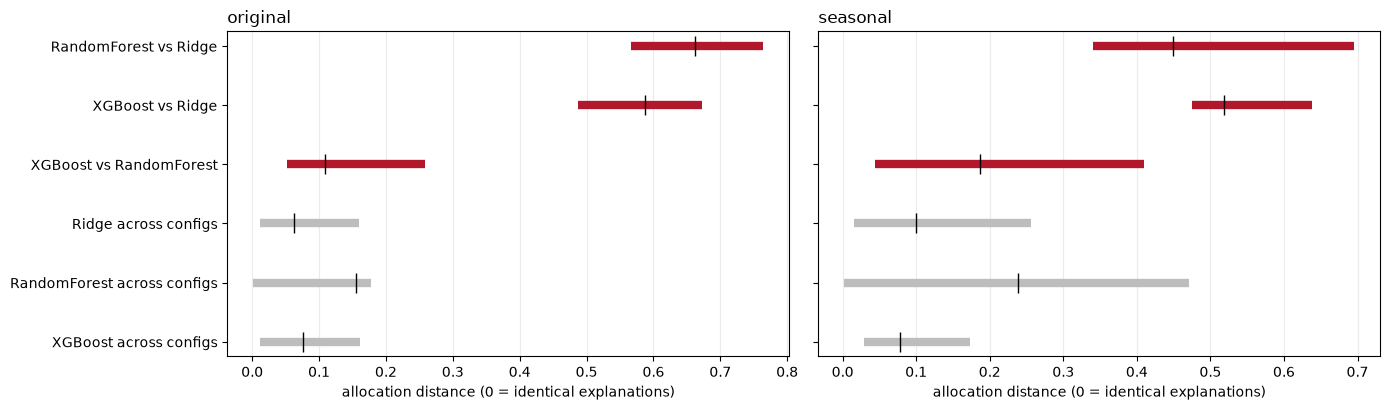

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for ax, b in zip(axes, BRANCHES):
    sub = rashomon[rashomon.branch == b].reset_index(drop=True)
    colors = ["#bdbdbd" if "across" in p else "#b2182b" for p in sub.pair]
    ax.hlines(range(len(sub)), sub.dist_lo, sub.dist_hi, color=colors, lw=6)
    ax.plot(sub.dist, range(len(sub)), "k|", ms=14)
    ax.set_yticks(range(len(sub)), sub.pair)
    ax.set_xlabel("allocation distance (0 = identical explanations)")
    ax.set_title(b, loc="left")
    ax.grid(alpha=0.25, axis="x")
fig.tight_layout()
fig.savefig("../figures/07_rashomon.png", dpi=150, bbox_inches="tight")
plt.show()

## Saving

In [6]:
rashomon.to_csv("../results/07_rashomon.csv", index=False)
print("saved")

saved
